# **Projeto de Detecção de Fraudes com transações via PIX**

## Business Understanding

##### **Contexto do problema:** setor, stakeholders, impacto esperado.
##### **Objetivo de negócio:** o que se quer resolver/melhorar, traduzido em linguagem executiva.
##### **Objetivo de mineração:** tradução técnica do objetivo (classificação, regressão, clustering, associação, detecção de anomalia).
##### **Critérios de sucesso:** como o grupo medirá se o projeto foi bem-sucedido — do ponto de vista técnico E de negócio.
##### **Premissas e restrições:** limitações éticas, legais (LGPD), temporais ou de dados.


## Data Understanding

##### **Origem dos dados:** fonte, forma de coleta, período coberto, licença.
##### **Dicionário de dados:** variáveis, tipos, significados e unidades.
##### **Análise Exploratória (EDA):** estatísticas descritivas, distribuições, correlações, outliers, valores faltantes.
##### **Hipóteses iniciais:** o que os dados sugerem antes de qualquer modelagem.
##### **Problemas identificados:** inconsistências, vieses, desbalanceamento, qualidade.


In [ ]:
import pandas as pd
from datetime import datetime
from google.colab import drive

In [ ]:
# Montando o Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Lendo os dados
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/pix_fraud_v2.csv")
print("Primeiras 5 linhas do dataset:")
df.head(5)

Primeiras 5 linhas do dataset:


,transaction_id,org_id,account_id,transaction_datetime,transaction_amount,pix_key_type,account_age_days,account_state,account_device,account_transactions_last_24h,account_avg_transaction_amount,internal_code,is_fraud
0,8cb6d811-b6f4-40e5-88e2-6aae9f7141b4,TN-D1XPP4DZ-HDS9,1881121,2023-08-10 07:56:09.937414431,2098.70,aleatoria,460,RS,mobile,2,1927.07,AUX-446658,0
1,4692b4fb-26a5-4fe5-85f4-40e3ca88924d,TN-01Z2SE4Q-SNG7,2336970,2023-02-16 06:53:36.964167879,1315.88,telefone,453,CE,desktop,3,1690.11,INT-615650,0
2,bcedca44-f38f-4727-a1a4-17b4c7adfee7,TN-01Z2SE4Q-SNG7,2338308,2023-11-08 12:45:42.739894783,2637.54,aleatoria,93,AM,mobile,2,1803.28,AUX-661205,0
3,2fb24e62-8619-47be-b4bd-a4f14e184a2c,TN-01Z2SE4Q-SNG7,2338446,2025-09-24 05:53:01.560295596,302.63,telefone,179,RJ,desktop,6,1897.99,SYS-916208,0
4,74d3bbf7-6fe5-4826-b084-eaddfac1a2ba,TN-D1XPP4DZ-HDS9,1879300,2023-12-21 11:39:03.265215192,1700.95,cpf,600,SP,mobile,1,2081.36,INT-572874,0


In [ ]:
#print("Informações sobre os tipos de dados em X_train após a codificação:")
#X_train.info()

In [ ]:
# Ordenando os dados pela data da transação para garantir que o split treino/teste seja temporalmente consistente.
# Garantindo que a coluna de data esteja no formato correto
df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"], errors="coerce")
df.sort_values(by="transaction_datetime", inplace=True)
print("Dataset ordenado pela data da transação:")

Dataset ordenado pela data da transação:


In [ ]:
# Exibindo informações gerais sobre o dataset (tipo de dados, valores não nulos).
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 402000 entries, 203341 to 356032
Data columns (total 13 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   transaction_id                  402000 non-null  object        
 1   org_id                          402000 non-null  object        
 2   account_id                      402000 non-null  int64         
 3   transaction_datetime            402000 non-null  datetime64[ns]
 4   transaction_amount              402000 non-null  float64       
 5   pix_key_type                    390056 non-null  object        
 6   account_age_days                402000 non-null  int64         
 7   account_state                   399944 non-null  object        
 8   account_device                  382038 non-null  object        
 9   account_transactions_last_24h   402000 non-null  int64         
 10  account_avg_transaction_amount  402000 non-null  float64

In [ ]:
# Removendo colunas que representam 'data leakage' (vazamento de informações) ou que não são úteis para o modelo preditivo.
# 'internal_code' é um identificador que pode ser gerado após a transação ser processada, revelando a fraude antes da previsão do modelo
df.drop(columns=["internal_code"], inplace=True)
print("Coluna 'internal_code' removida.")

Coluna 'internal_code' removida.


In [ ]:
print("Visualizando as primeiras linhas do DataFrame após a remoção de colunas:")
df.head()

Visualizando as primeiras linhas do DataFrame após a remoção de colunas:


,transaction_id,org_id,account_id,transaction_datetime,transaction_amount,pix_key_type,account_age_days,account_state,account_device,account_transactions_last_24h,account_avg_transaction_amount,is_fraud
203341,a610b1a5-4db9-491b-a025-c1e3bf3c89bb,TN-01Z2SE4Q-SNG7,2337290,2023-01-01 00:07:26.951918532,852.38,aleatoria,191,AC,mobile,1,2279.08,0
141981,8b108f13-0c0c-441c-ba83-c93e24853504,TN-D1XPP4DZ-HDS9,1879806,2023-01-01 00:23:47.545692149,4422.41,cpf,154,rj,desktop,4,900.57,0
195696,8edfe566-3dc5-4ee7-b7ed-e526d8f08320,TN-01Z2SE4Q-SNG7,2338402,2023-01-01 00:34:16.986899863,5150.12,cpf,45,RO,tablet,0,1461.34,1
341027,c686fbce-c213-410c-8953-91ecabf3c8ab,TN-D1XPP4DZ-HDS9,1879398,2023-01-01 00:43:49.980200080,1865.83,email,524,BA,tablet,1,1735.11,0
168718,c8ea9dce-7ba7-474e-9589-617f2558ec7b,TN-01Z2SE4Q-SNG7,2337604,2023-01-01 00:51:33.672867988,197.95,email,446,MG,mobile,1,2251.08,1


In [ ]:
# Contagem total de casos de fraude ('is_fraud' = 1).
fraud_count = df["is_fraud"].sum()
print(f"Número total de casos de fraude: {fraud_count}")

Número total de casos de fraude: 11738


In [ ]:
# Calculando a porcentagem de casos de fraude no dataset para verificar o desbalanceamento.
pct_1 = 100 * df["is_fraud"].sum() / df.shape[0]
print(f"Porcentagem de casos de fraude (Classe 1): {pct_1:.2f}%")

# Observamos um desbalanceamento significativo na classe 'is_fraud', o que é comum em problemas de detecção de fraude.

Porcentagem de casos de fraude (Classe 1): 2.92%


## 3. Preparação dos Dados (Data Preparation)

Nesta fase, os dados são limpos, transformados e construídos para serem adequados para a modelagem.

### Divisão do Dataset em Treino e Teste

Dividimos o dataset em conjuntos de treino e teste para avaliar a performance do modelo em dados não vistos. É crucial manter a ordem temporal (shuffle=False) devido à natureza dos dados de tempo.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  df.drop(columns=["is_fraud"]),
  df[["is_fraud"]],
  test_size=0.2,
  shuffle=False  # Manter a ordem temporal
)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

Shape de X_train: (321600, 11)
Shape de X_test: (80400, 11)
Shape de y_train: (321600, 1)
Shape de y_test: (80400, 1)


In [ ]:
# Resetando os índices dos DataFrames de treino e teste para evitar problemas de alinhamento em operações futuras.
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

print("Índices dos conjuntos de treino e teste resetados.")

Índices dos conjuntos de treino e teste resetados.


In [ ]:
X_train.tail()

,transaction_id,org_id,account_id,transaction_datetime,transaction_amount,pix_key_type,account_age_days,account_state,account_device,account_transactions_last_24h,account_avg_transaction_amount
321595,8d68af5c-50c9-4528-ab7b-6bbe99562169,TN-Y21HNQRB-TF0Y,2176930,2025-05-25 11:39:44.539909770,795.58,email,1211,MS,mobile,3,929.46
321596,6c74bb84-7d19-473a-bd3b-667782aeaea5,TN-01Z2SE4Q-SNG7,2337301,2025-05-25 11:39:58.943068956,748.98,email,75,AL,desktop,2,2961.91
321597,19dd7832-6897-45d5-9e00-055e0425abbe,TN-D1XPP4DZ-HDS9,1879967,2025-05-25 11:40:47.078115313,3026.66,email,15,RJ,mobile,1,961.05
321598,690d1deb-5c9b-48cd-9f60-69687d5bab17,TN-01Z2SE4Q-SNG7,2336936,2025-05-25 11:40:57.750930348,6171.04,telefone,821,RJ,mobile,5,2330.20
321599,e7bcda14-e885-4c74-bc05-936d645d600e,TN-01Z2SE4Q-SNG7,2336883,2025-05-25 11:42:26.340095702,3752.21,cpf,585,PR,tablet,4,1982.72


In [ ]:
X_test.head()

,transaction_id,org_id,account_id,transaction_datetime,transaction_amount,pix_key_type,account_age_days,account_state,account_device,account_transactions_last_24h,account_avg_transaction_amount
0,ffe95225-4a74-4d40-9b5e-d9294fd84793,TN-D1XPP4DZ-HDS9,1880832,2025-05-25 11:43:03.581097025,3003.39,email,547,SP,mobile,2,1325.11
1,686e7318-71e8-4f5f-bd7f-cf2d15a33a0d,TN-D1XPP4DZ-HDS9,1879835,2025-05-25 11:43:10.451696244,7351.24,email,189,mg,mobile,3,847.35
2,739017d0-97e0-459e-8042-8c6df26a3b8e,TN-2XO3TPQI-DT5C,1214799,2025-05-25 11:43:28.539054316,1752.11,email,197,GO,tablet,1,437.60
3,f6ee7b70-8463-4d1f-9636-88b1e035594b,TN-D1XPP4DZ-HDS9,1880766,2025-05-25 11:46:12.347601149,5505.35,cpf,29,ES,mobile,0,1856.97
4,1315be15-8df3-46b5-9481-498ad3fe8c9b,TN-D1XPP4DZ-HDS9,1879578,2025-05-25 11:47:23.378184517,2786.36,NaN,1419,SC.,mobile,1,1720.34


In [ ]:
X_train.head()

,transaction_id,org_id,account_id,transaction_datetime,transaction_amount,pix_key_type,account_age_days,account_state,account_device,account_transactions_last_24h,account_avg_transaction_amount
0,a610b1a5-4db9-491b-a025-c1e3bf3c89bb,TN-01Z2SE4Q-SNG7,2337290,2023-01-01 00:07:26.951918532,852.38,aleatoria,191,AC,mobile,1,2279.08
1,8b108f13-0c0c-441c-ba83-c93e24853504,TN-D1XPP4DZ-HDS9,1879806,2023-01-01 00:23:47.545692149,4422.41,cpf,154,rj,desktop,4,900.57
2,8edfe566-3dc5-4ee7-b7ed-e526d8f08320,TN-01Z2SE4Q-SNG7,2338402,2023-01-01 00:34:16.986899863,5150.12,cpf,45,RO,tablet,0,1461.34
3,c686fbce-c213-410c-8953-91ecabf3c8ab,TN-D1XPP4DZ-HDS9,1879398,2023-01-01 00:43:49.980200080,1865.83,email,524,BA,tablet,1,1735.11
4,c8ea9dce-7ba7-474e-9589-617f2558ec7b,TN-01Z2SE4Q-SNG7,2337604,2023-01-01 00:51:33.672867988,197.95,email,446,MG,mobile,1,2251.08


### Processamento da Coluna de Data ('transaction_datetime')

Extraímos características temporais da transação, como hora, dia, mês, ano, dia da semana, final de semana e madrugada. Essas variáveis podem ajudar o modelo a identificar padrões temporais associados a fraudes.

In [ ]:
# Garante que a coluna esteja em formato datetime
X_train["transaction_datetime"] = pd.to_datetime(
        X_train["transaction_datetime"],
        errors="coerce"
    )

# Extração de variáveis temporais
X_train["transaction_hour"] = X_train["transaction_datetime"].dt.hour
X_train["transaction_day"] = X_train["transaction_datetime"].dt.day
X_train["transaction_month"] = X_train["transaction_datetime"].dt.month
X_train["transaction_year"] = X_train["transaction_datetime"].dt.year
X_train["transaction_dayofweek"] = X_train["transaction_datetime"].dt.dayofweek

# Features derivadas
X_train["is_weekend"] = X_train["transaction_dayofweek"].isin([5, 6]).astype(int)
X_train["is_night"] = X_train["transaction_hour"].between(0, 5).astype(int)

# Remove a coluna original de data/hora, pois o modelo não trabalha diretamente com datetime
X_train = X_train.drop(columns=["transaction_datetime"])

X_train.head()

,transaction_id,org_id,account_id,transaction_amount,pix_key_type,account_age_days,account_state,account_device,account_transactions_last_24h,account_avg_transaction_amount,transaction_hour,transaction_day,transaction_month,transaction_year,transaction_dayofweek,is_weekend,is_night
0,a610b1a5-4db9-491b-a025-c1e3bf3c89bb,TN-01Z2SE4Q-SNG7,2337290,852.38,aleatoria,191,AC,mobile,1,2279.08,0,1,1,2023,6,1,1
1,8b108f13-0c0c-441c-ba83-c93e24853504,TN-D1XPP4DZ-HDS9,1879806,4422.41,cpf,154,rj,desktop,4,900.57,0,1,1,2023,6,1,1
2,8edfe566-3dc5-4ee7-b7ed-e526d8f08320,TN-01Z2SE4Q-SNG7,2338402,5150.12,cpf,45,RO,tablet,0,1461.34,0,1,1,2023,6,1,1
3,c686fbce-c213-410c-8953-91ecabf3c8ab,TN-D1XPP4DZ-HDS9,1879398,1865.83,email,524,BA,tablet,1,1735.11,0,1,1,2023,6,1,1
4,c8ea9dce-7ba7-474e-9589-617f2558ec7b,TN-01Z2SE4Q-SNG7,2337604,197.95,email,446,MG,mobile,1,2251.08,0,1,1,2023,6,1,1


In [ ]:
# Garante que a coluna esteja em formato datetime
X_test["transaction_datetime"] = pd.to_datetime(
        X_test["transaction_datetime"],
        errors="coerce"
    )

# Extração de variáveis temporais
X_test["transaction_hour"] = X_test["transaction_datetime"].dt.hour
X_test["transaction_day"] = X_test["transaction_datetime"].dt.day
X_test["transaction_month"] = X_test["transaction_datetime"].dt.month
X_test["transaction_year"] = X_test["transaction_datetime"].dt.year
X_test["transaction_dayofweek"] = X_test["transaction_datetime"].dt.dayofweek

# Features derivadas
X_test["is_weekend"] = X_test["transaction_dayofweek"].isin([5, 6]).astype(int)
X_test["is_night"] = X_test["transaction_hour"].between(0, 5).astype(int)

# Remove a coluna original de data/hora, pois o modelo não trabalha diretamente com datetime
X_test = X_test.drop(columns=["transaction_datetime"])

X_test.head()

,transaction_id,org_id,account_id,transaction_amount,pix_key_type,account_age_days,account_state,account_device,account_transactions_last_24h,account_avg_transaction_amount,transaction_hour,transaction_day,transaction_month,transaction_year,transaction_dayofweek,is_weekend,is_night
0,ffe95225-4a74-4d40-9b5e-d9294fd84793,TN-D1XPP4DZ-HDS9,1880832,3003.39,email,547,SP,mobile,2,1325.11,11,25,5,2025,6,1,0
1,686e7318-71e8-4f5f-bd7f-cf2d15a33a0d,TN-D1XPP4DZ-HDS9,1879835,7351.24,email,189,mg,mobile,3,847.35,11,25,5,2025,6,1,0
2,739017d0-97e0-459e-8042-8c6df26a3b8e,TN-2XO3TPQI-DT5C,1214799,1752.11,email,197,GO,tablet,1,437.60,11,25,5,2025,6,1,0
3,f6ee7b70-8463-4d1f-9636-88b1e035594b,TN-D1XPP4DZ-HDS9,1880766,5505.35,cpf,29,ES,mobile,0,1856.97,11,25,5,2025,6,1,0
4,1315be15-8df3-46b5-9481-498ad3fe8c9b,TN-D1XPP4DZ-HDS9,1879578,2786.36,NaN,1419,SC.,mobile,1,1720.34,11,25,5,2025,6,1,0


### Processamento de Variáveis Categóricas

Identificamos as variáveis categóricas e aplicamos técnicas de codificação (Label Encoding e One-Hot Encoding) para transformá-las em um formato numérico, adequado para os algoritmos de Machine Learning.

In [ ]:
print("Informações sobre os tipos de dados em X_train antes da codificação:")
X_train.info()

Informações sobre os tipos de dados em X_train antes da codificação:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321600 entries, 0 to 321599
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   transaction_id                  321600 non-null  object 
 1   org_id                          321600 non-null  object 
 2   account_id                      321600 non-null  int64  
 3   transaction_amount              321600 non-null  float64
 4   pix_key_type                    312001 non-null  object 
 5   account_age_days                321600 non-null  int64  
 6   account_state                   319957 non-null  object 
 7   account_device                  305630 non-null  object 
 8   account_transactions_last_24h   321600 non-null  int64  
 9   account_avg_transaction_amount  321600 non-null  float64
 10  transaction_hour                321600 non-null  int32  
 11  transacti

In [ ]:
# Removendo identificadores que não devem ser usados diretamente pelo modelo
# Eles podem gerar memorização em vez de aprendizado real.
cols_identificadores = ["transaction_id", "account_id", "internal_code"]

X_train = X_train.drop(columns=cols_identificadores, errors="ignore")
X_test = X_test.drop(columns=cols_identificadores, errors="ignore")

print("Colunas identificadoras removidas.")
print(X_train.columns)

Colunas identificadoras removidas.
Index(['org_id', 'transaction_amount', 'pix_key_type', 'account_age_days',
       'account_state', 'account_device', 'account_transactions_last_24h',
       'account_avg_transaction_amount', 'transaction_hour', 'transaction_day',
       'transaction_month', 'transaction_year', 'transaction_dayofweek',
       'is_weekend', 'is_night'],
      dtype='object')


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321600 entries, 0 to 321599
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   org_id                          321600 non-null  object 
 1   transaction_amount              321600 non-null  float64
 2   pix_key_type                    312001 non-null  object 
 3   account_age_days                321600 non-null  int64  
 4   account_state                   319957 non-null  object 
 5   account_device                  305630 non-null  object 
 6   account_transactions_last_24h   321600 non-null  int64  
 7   account_avg_transaction_amount  321600 non-null  float64
 8   transaction_hour                321600 non-null  int32  
 9   transaction_day                 321600 non-null  int32  
 10  transaction_month               321600 non-null  int32  
 11  transaction_year                321600 non-null  int32  
 12  transaction_dayo

### Tratamento de Valores Nulos e Inconsistências

Foram tratados valores nulos em variáveis categóricas, como tipo de chave PIX, dispositivo e estado da conta. Também foram padronizados estados brasileiros, criadas flags para valores negativos e construída uma feature comparando o valor da transação com o valor médio histórico da conta.

In [ ]:
# Lista de UFs válidas no Brasil
ufs_validas = {
    "AC", "AL", "AP", "AM", "BA", "CE", "DF", "ES", "GO",
    "MA", "MT", "MS", "MG", "PA", "PB", "PR", "PE", "PI",
    "RJ", "RN", "RS", "RO", "RR", "SC", "SP", "SE", "TO"
}

for base in [X_train, X_test]:

    # Padronização da UF
    base["account_state"] = (
        base["account_state"]
        .astype("string")
        .str.upper()
        .str.strip()
        .str.replace(".", "", regex=False)
    )

    # Estados inválidos viram UNKNOWN
    base.loc[~base["account_state"].isin(ufs_validas), "account_state"] = "UNKNOWN"

    # Tratamento de valores nulos em variáveis categóricas (SUBSTITUINDO POR 'missing')
    base["pix_key_type"] = base["pix_key_type"].fillna("missing")
    base["account_device"] = base["account_device"].fillna("missing")
    base["account_state"] = base["account_state"].fillna("UNKNOWN")

    # Criando flags para valores negativos
    base["amount_negative_flag"] = (base["transaction_amount"] < 0).astype(int)
    base["account_age_negative_flag"] = (base["account_age_days"] < 0).astype(int)

    # Corrigindo valores negativos para não prejudicar o modelo (TRANSFORMA EM POSITIVO)
    base["transaction_amount"] = base["transaction_amount"].abs()
    base["account_age_days"] = base["account_age_days"].clip(lower=0)

    # Feature comparando o valor da transação com a média histórica da conta
    base["amount_vs_avg_ratio"] = (
        base["transaction_amount"] / (base["account_avg_transaction_amount"] + 1)
    )

print("Tratamento de nulos, inconsistências e criação de features concluído.")

print("Nulos em X_train:")
print(X_train.isnull().sum())

print("Nulos em X_test:")
print(X_test.isnull().sum())

Tratamento de nulos, inconsistências e criação de features concluído.
Nulos em X_train:
org_id                            0
transaction_amount                0
pix_key_type                      0
account_age_days                  0
account_state                     0
account_device                    0
account_transactions_last_24h     0
account_avg_transaction_amount    0
transaction_hour                  0
transaction_day                   0
transaction_month                 0
transaction_year                  0
transaction_dayofweek             0
is_weekend                        0
is_night                          0
amount_negative_flag              0
account_age_negative_flag         0
amount_vs_avg_ratio               0
dtype: int64
Nulos em X_test:
org_id                            0
transaction_amount                0
pix_key_type                      0
account_age_days                  0
account_state                     0
account_device                    0
account_transactio

### Codificar variáveis categóricas

Uitlizaremos apenas o OneHotEncoder pois essas categorias (cpf, email, telefone) não possuem ordem natural.

Não existe uma chave PIX “maior” ou “menor” que a outra. Por isso, usar LabelEncoder poderia criar uma ordem artificial e confundir alguns modelos.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Variáveis categóricas reais do dataset PIX
categorical_cols = [
    "org_id",
    "pix_key_type",
    "account_state",
    "account_device"
]

# Variáveis numéricas: todas as que não são categóricas
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

# Compatibilidade entre versões diferentes do scikit-learn
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Ajusta o encoder no treino e aplica no treino
encoded_train = encoder.fit_transform(X_train[categorical_cols])

# Aplica o mesmo encoder no teste
encoded_test = encoder.transform(X_test[categorical_cols])

# Nomes das novas colunas criadas pelo OneHotEncoder
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Transformando arrays em DataFrames
X_train_encoded = pd.DataFrame(
    encoded_train,
    columns=encoded_cols,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    encoded_test,
    columns=encoded_cols,
    index=X_test.index
)

# Juntando variáveis numéricas com variáveis categóricas codificadas
X_train = pd.concat([X_train[numeric_cols], X_train_encoded], axis=1)
X_test = pd.concat([X_test[numeric_cols], X_test_encoded], axis=1)

print("Variáveis categóricas codificadas com OneHotEncoder.")
print(f"Shape final de X_train: {X_train.shape}")
print(f"Shape final de X_test: {X_test.shape}")

X_train.head()

Variáveis categóricas codificadas com OneHotEncoder.
Shape final de X_train: (321600, 61)
Shape final de X_test: (80400, 61)


,transaction_amount,account_age_days,account_transactions_last_24h,account_avg_transaction_amount,transaction_hour,transaction_day,transaction_month,transaction_year,transaction_dayofweek,is_weekend,...,account_state_RS,account_state_SC,account_state_SE,account_state_SP,account_state_TO,account_state_UNKNOWN,account_device_desktop,account_device_missing,account_device_mobile,account_device_tablet
0,852.38,191,1,2279.08,0,1,1,2023,6,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,4422.41,154,4,900.57,0,1,1,2023,6,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,5150.12,45,0,1461.34,0,1,1,2023,6,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1865.83,524,1,1735.11,0,1,1,2023,6,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,197.95,446,1,2251.08,0,1,1,2023,6,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Checagem final da preparação

In [ ]:
print("Resumo final da preparação dos dados:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\nTotal de nulos em X_train:", X_train.isnull().sum().sum())
print("Total de nulos em X_test:", X_test.isnull().sum().sum())

print("\nTipos de dados em X_train:")
print(X_train.dtypes.value_counts())

Resumo final da preparação dos dados:
X_train: (321600, 61)
X_test: (80400, 61)
y_train: (321600, 1)
y_test: (80400, 1)

Total de nulos em X_train: 0
Total de nulos em X_test: 0

Tipos de dados em X_train:
float64    50
int64       6
int32       5
Name: count, dtype: int64


In [ ]:
# Ajustando o formato da variável alvo
# O sklearn trabalha melhor quando y é uma Series 1D, e não um DataFrame com uma coluna.

y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Garantindo que a variável alvo esteja como inteiro
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print(f"y_train ajustado: {y_train.shape}")
print(f"y_test ajustado: {y_test.shape}")

print("\nDistribuição da variável alvo no treino:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição da variável alvo no teste:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

y_train ajustado: (321600,)
y_test ajustado: (80400,)

Distribuição da variável alvo no treino:
is_fraud
0    312233
1      9367
Name: count, dtype: int64
is_fraud
0    97.087376
1     2.912624
Name: proportion, dtype: float64

Distribuição da variável alvo no teste:
is_fraud
0    78029
1     2371
Name: count, dtype: int64
is_fraud
0    97.050995
1     2.949005
Name: proportion, dtype: float64


### Função de Avaliação dos Modelos

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

def avaliar_modelo(nome_modelo, y_real, y_pred, y_proba=None):
    print("=" * 60)
    print(f"Modelo: {nome_modelo}")
    print("=" * 60)

    print(f"Acurácia:  {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_real, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_real, y_pred, zero_division=0):.4f}")
    print(f"F1-score:  {f1_score(y_real, y_pred, zero_division=0):.4f}")

    if y_proba is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_real, y_proba):.4f}")
        print(f"PR-AUC:    {average_precision_score(y_real, y_proba):.4f}")

    print("\nMatriz de confusão:")
    print(confusion_matrix(y_real, y_pred))

    print("\nRelatório de classificação:")
    print(classification_report(y_real, y_pred, zero_division=0))

Por que isso é estamos inserindo uma função de avaliação dos modelos?

Porque fraude é um problema desbalanceado.

Se só usarmos acurácia, podemos nos enganar. Um modelo que diz “não é fraude” para todo mundo pode ter acurácia alta, mas ser inútil para detectar fraude.

Aqui o mais importante será observar:

Recall: de todas as fraudes reais, quantas o modelo conseguiu pegar?
Precisão: de tudo que o modelo marcou como fraude, quanto realmente era fraude?
PR-AUC: métrica muito útil quando a classe positiva é rara.
Matriz de confusão: mostra falsos positivos e falsos negativos.

## 4. Modelagem (Modeling)

Nesta fase, selecionamos e treinamos o modelo de Machine Learning para a detecção de fraude.

Seguiremos a modelagem da seguinte maneira:


1.   Modelo baseline: um modelo burro que sempre prevê “não fraude”.
2.   Regressão logística / modelo linear: simples, interpretável e bom para comparação.
3.   Árvore de decisão: também simples, explicável e diferente da regressão logística.
4.   Avaliação com métricas corretas: precision, recall, F1, ROC-AUC, PR-AUC e matriz de confusão.

## Modelo Baseline

In [ ]:
from sklearn.dummy import DummyClassifier

# Modelo baseline: sempre prevê a classe mais frequente
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

avaliar_modelo(
    nome_modelo="Baseline - sempre prevê não fraude",
    y_real=y_test,
    y_pred=y_pred_baseline
)

Modelo: Baseline - sempre prevê não fraude
Acurácia:  0.9705
Precisão:  0.0000
Recall:    0.0000
F1-score:  0.0000

Matriz de confusão:
[[78029     0]
 [ 2371     0]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     78029
           1       0.00      0.00      0.00      2371

    accuracy                           0.97     80400
   macro avg       0.49      0.50      0.49     80400
weighted avg       0.94      0.97      0.96     80400



### Interpretação do modelo baseline

O modelo baseline apresentou acurácia de aproximadamente 97%, mas não identificou nenhuma fraude. Isso ocorre porque a base é altamente desbalanceada: a maior parte das transações é legítima.

Portanto, a acurácia isolada não é uma métrica adequada para este problema. Em detecção de fraude, métricas como recall, precisão, F1-score, PR-AUC e matriz de confusão são mais relevantes, pois avaliam a capacidade do modelo de identificar corretamente a classe minoritária, que neste caso é a fraude.

## Regressão Logística

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Modelo 1: Regressão Logística com balanceamento de classes
# Usamos class_weight="balanced" porque a classe fraude é muito menor que a classe não fraude.

modelo_logistico = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Treinamento do modelo
modelo_logistico.fit(X_train, y_train)

# Predição das classes
y_pred_logistico = modelo_logistico.predict(X_test)

# Predição das probabilidades da classe fraude
y_proba_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

# Avaliação
avaliar_modelo(
    nome_modelo="Regressão Logística com class_weight balanced",
    y_real=y_test,
    y_pred=y_pred_logistico,
    y_proba=y_proba_logistico
)

Modelo: Regressão Logística com class_weight balanced
Acurácia:  0.8142
Precisão:  0.0960
Recall:    0.6301
F1-score:  0.1667
ROC-AUC:   0.7779
PR-AUC:    0.1118

Matriz de confusão:
[[63968 14061]
 [  877  1494]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     78029
           1       0.10      0.63      0.17      2371

    accuracy                           0.81     80400
   macro avg       0.54      0.72      0.53     80400
weighted avg       0.96      0.81      0.87     80400



### Interpretação da Regressão Logística

A Regressão Logística com `class_weight="balanced"` apresentou desempenho superior ao baseline na identificação de fraudes. Enquanto o baseline não detectava nenhuma fraude, o modelo logístico conseguiu identificar aproximadamente 63% das transações fraudulentas.

Por outro lado, a precisão da classe fraude ficou baixa, indicando que muitas transações legítimas foram classificadas como suspeitas. Esse comportamento é esperado em problemas de fraude, pois a classe positiva é rara e o custo de deixar uma fraude passar pode ser maior do que o custo de revisar uma transação legítima.

Assim, a decisão do limiar de classificação não deve ser apenas técnica, mas também de negócio. Um limiar mais baixo aumenta o recall, capturando mais fraudes, mas também aumenta os falsos positivos. Um limiar mais alto reduz falsos positivos, mas pode deixar mais fraudes passarem.

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def avaliar_thresholds(y_real, y_proba, thresholds):
    resultados = []

    for threshold in thresholds:
        y_pred_threshold = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_real, y_pred_threshold).ravel()

        precision = precision_score(y_real, y_pred_threshold, zero_division=0)
        recall = recall_score(y_real, y_pred_threshold, zero_division=0)
        f1 = f1_score(y_real, y_pred_threshold, zero_division=0)

        resultados.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "verdadeiros_positivos": tp,
            "falsos_positivos": fp,
            "falsos_negativos": fn,
            "verdadeiros_negativos": tn
        })

    return pd.DataFrame(resultados)

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

resultado_thresholds_logistico = avaliar_thresholds(
    y_real=y_test,
    y_proba=y_proba_logistico,
    thresholds=thresholds
)

resultado_thresholds_logistico

,threshold,precision,recall,f1_score,verdadeiros_positivos,falsos_positivos,falsos_negativos,verdadeiros_negativos
0,0.3,0.045625,0.860818,0.086657,2041,42693,330,35336
1,0.4,0.066826,0.730493,0.122450,1732,24186,639,53843
2,0.5,0.096046,0.630114,0.166685,1494,14061,877,63968
3,0.6,0.106652,0.586251,0.180473,1390,11643,981,66386
4,0.7,0.110156,0.567271,0.184487,1345,10865,1026,67164
5,0.8,0.148680,0.301561,0.199164,715,4094,1656,73935
6,0.9,0.208791,0.008013,0.015435,19,72,2352,77957


In [ ]:
import numpy as np
from sklearn.metrics import fbeta_score

thresholds_detalhados = np.arange(0.05, 0.95, 0.01)

resultados_f2 = []

for threshold in thresholds_detalhados:
    y_pred_threshold = (y_proba_logistico >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    f2 = fbeta_score(y_test, y_pred_threshold, beta=2, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    resultados_f2.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "f2_score": f2,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

df_resultados_f2 = pd.DataFrame(resultados_f2)

melhor_linha = df_resultados_f2.loc[df_resultados_f2["f2_score"].idxmax()]

print("Melhor threshold pelo F2-score:")
print(melhor_linha)

df_resultados_f2.sort_values("f2_score", ascending=False).head(10)

Melhor threshold pelo F2-score:
threshold        0.710000
precision        0.112271
recall           0.557992
f1_score         0.186930
f2_score         0.311031
tp            1323.000000
fp           10461.000000
fn            1048.000000
tn           67568.000000
Name: 66, dtype: float64


,threshold,precision,recall,f1_score,f2_score,tp,fp,fn,tn
66,0.71,0.112271,0.557992,0.186930,0.311031,1323,10461,1048,67568
59,0.64,0.108095,0.582876,0.182370,0.310297,1382,11403,989,66626
64,0.69,0.109326,0.574019,0.183671,0.310263,1361,11088,1010,66941
61,0.66,0.108348,0.580768,0.182626,0.310233,1377,11332,994,66697
60,0.65,0.108216,0.581611,0.182480,0.310208,1379,11364,992,66665
65,0.70,0.110156,0.567271,0.184487,0.309994,1345,10865,1026,67164
62,0.67,0.108435,0.579081,0.182665,0.309988,1373,11289,998,66740
63,0.68,0.108718,0.576972,0.182961,0.309965,1368,11215,1003,66814
58,0.63,0.107803,0.583298,0.181974,0.309909,1383,11446,988,66583
57,0.62,0.107556,0.584142,0.181663,0.309691,1385,11492,986,66537


In [ ]:
melhor_threshold_logistico = melhor_linha["threshold"]

y_pred_logistico_ajustado = (y_proba_logistico >= melhor_threshold_logistico).astype(int)

avaliar_modelo(
    nome_modelo=f"Regressão Logística com threshold ajustado ({melhor_threshold_logistico:.2f})",
    y_real=y_test,
    y_pred=y_pred_logistico_ajustado,
    y_proba=y_proba_logistico
)

Modelo: Regressão Logística com threshold ajustado (0.71)
Acurácia:  0.8569
Precisão:  0.1123
Recall:    0.5580
F1-score:  0.1869
ROC-AUC:   0.7779
PR-AUC:    0.1118

Matriz de confusão:
[[67568 10461]
 [ 1048  1323]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     78029
           1       0.11      0.56      0.19      2371

    accuracy                           0.86     80400
   macro avg       0.55      0.71      0.55     80400
weighted avg       0.96      0.86      0.90     80400



### Análise do ajuste de threshold

Após o treinamento da Regressão Logística, avaliamos diferentes limiares de classificação. O limiar padrão de 0,50 apresentou maior recall, identificando mais fraudes, porém gerou um volume elevado de falsos positivos.

Ao ajustar o threshold para aproximadamente 0,70, o modelo reduziu a quantidade de falsos positivos, aumentando a precisão da classe fraude, ainda que com perda moderada de recall. Essa escolha representa um trade-off entre segurança e custo operacional.

Em um ambiente real de prevenção a fraudes, a escolha do threshold dependeria do custo financeiro de uma fraude não detectada, do impacto de bloquear ou revisar transações legítimas e da capacidade operacional da equipe responsável pela análise dos alertas.

## Árvore de Decisão

Essa modelagem nos permitirá discutir regras do tipo: se a transação tem valor alto, ocorre em determinado horário e usa determinado tipo de chave. Esses fatores podem determionar o aumento da probabilidade de fraude.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Modelo 2: Árvore de Decisão
# Limitamos a profundidade para evitar overfitting e manter o modelo mais interpretável.

modelo_arvore = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42
)

# Treinamento
modelo_arvore.fit(X_train, y_train)

# Predição das classes
y_pred_arvore = modelo_arvore.predict(X_test)

# Predição das probabilidades da classe fraude
y_proba_arvore = modelo_arvore.predict_proba(X_test)[:, 1]

# Avaliação
avaliar_modelo(
    nome_modelo="Árvore de Decisão com class_weight balanced",
    y_real=y_test,
    y_pred=y_pred_arvore,
    y_proba=y_proba_arvore
)

Modelo: Árvore de Decisão com class_weight balanced
Acurácia:  0.8015
Precisão:  0.0911
Recall:    0.6385
F1-score:  0.1595
ROC-AUC:   0.7731
PR-AUC:    0.1066

Matriz de confusão:
[[62925 15104]
 [  857  1514]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     78029
           1       0.09      0.64      0.16      2371

    accuracy                           0.80     80400
   macro avg       0.54      0.72      0.52     80400
weighted avg       0.96      0.80      0.87     80400



In [ ]:
resultado_thresholds_arvore = avaliar_thresholds(
    y_real=y_test,
    y_proba=y_proba_arvore,
    thresholds=thresholds
)

resultado_thresholds_arvore

,threshold,precision,recall,f1_score,verdadeiros_positivos,falsos_positivos,falsos_negativos,verdadeiros_negativos
0,0.3,0.049974,0.823281,0.094229,1952,37108,419,40921
1,0.4,0.063900,0.746099,0.117718,1769,25915,602,52114
2,0.5,0.091106,0.638549,0.159461,1514,15104,857,62925
3,0.6,0.090948,0.633910,0.159073,1503,15023,868,63006
4,0.7,0.110052,0.550401,0.183428,1305,10553,1066,67476
5,0.8,0.141572,0.331927,0.198487,787,4772,1584,73257
6,0.9,0.209770,0.030789,0.053696,73,275,2298,77754


In [ ]:
thresholds_detalhados = np.arange(0.05, 0.95, 0.01)

resultados_f2_arvore = []

for threshold in thresholds_detalhados:
    y_pred_threshold = (y_proba_arvore >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    f2 = fbeta_score(y_test, y_pred_threshold, beta=2, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    resultados_f2_arvore.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "f2_score": f2,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

df_resultados_f2_arvore = pd.DataFrame(resultados_f2_arvore)

melhor_linha_arvore = df_resultados_f2_arvore.loc[df_resultados_f2_arvore["f2_score"].idxmax()]

print("Melhor threshold da árvore pelo F2-score:")
print(melhor_linha_arvore)

df_resultados_f2_arvore.sort_values("f2_score", ascending=False).head(10)

Melhor threshold da árvore pelo F2-score:
threshold        0.620000
precision        0.108117
recall           0.573598
f1_score         0.181940
f2_score         0.308208
tp            1360.000000
fp           11219.000000
fn            1011.000000
tn           66810.000000
Name: 57, dtype: float64


,threshold,precision,recall,f1_score,f2_score,tp,fp,fn,tn
60,0.65,0.108117,0.573598,0.181940,0.308208,1360,11219,1011,66810
57,0.62,0.108117,0.573598,0.181940,0.308208,1360,11219,1011,66810
62,0.67,0.108117,0.573598,0.181940,0.308208,1360,11219,1011,66810
59,0.64,0.108117,0.573598,0.181940,0.308208,1360,11219,1011,66810
58,0.63,0.108117,0.573598,0.181940,0.308208,1360,11219,1011,66810
61,0.66,0.108117,0.573598,0.181940,0.308208,1360,11219,1011,66810
63,0.68,0.108117,0.573598,0.181940,0.308208,1360,11219,1011,66810
68,0.73,0.110527,0.549979,0.184064,0.306362,1304,10494,1067,67535
67,0.72,0.110527,0.549979,0.184064,0.306362,1304,10494,1067,67535
56,0.61,0.104778,0.590046,0.177956,0.306315,1399,11953,972,66076


In [ ]:
melhor_threshold_arvore = melhor_linha_arvore["threshold"]

y_pred_arvore_ajustado = (y_proba_arvore >= melhor_threshold_arvore).astype(int)

avaliar_modelo(
    nome_modelo=f"Árvore de Decisão com threshold ajustado ({melhor_threshold_arvore:.2f})",
    y_real=y_test,
    y_pred=y_pred_arvore_ajustado,
    y_proba=y_proba_arvore
)

Modelo: Árvore de Decisão com threshold ajustado (0.62)
Acurácia:  0.8479
Precisão:  0.1081
Recall:    0.5736
F1-score:  0.1819
ROC-AUC:   0.7731
PR-AUC:    0.1066

Matriz de confusão:
[[66810 11219]
 [ 1011  1360]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     78029
           1       0.11      0.57      0.18      2371

    accuracy                           0.85     80400
   macro avg       0.55      0.71      0.55     80400
weighted avg       0.96      0.85      0.89     80400



## 5. Avaliação (Evaluation)

Nesta fase, avaliamos a performance do modelo em dados de teste não vistos e determinamos sua eficácia na detecção de fraudes.

### Comparação dos modelos

Foram avaliadas duas abordagens principais: Regressão Logística e Árvore de Decisão, além de um modelo baseline. O baseline apresentou alta acurácia, mas não identificou nenhuma fraude, evidenciando que a acurácia isolada não é adequada para este problema.

A Regressão Logística e a Árvore de Decisão apresentaram desempenhos semelhantes em termos de ROC-AUC e recall. A Árvore de Decisão conseguiu capturar ligeiramente mais fraudes em alguns thresholds, porém gerou maior número de falsos positivos.

A Regressão Logística com threshold ajustado apresentou o melhor equilíbrio geral, com maior precisão, maior F1-score, maior PR-AUC e menor volume de falsos positivos em comparação com a árvore ajustada. Por esse motivo, foi selecionada como modelo mais adequado entre as abordagens testadas.

A decisão final, entretanto, depende do contexto de negócio. Em um ambiente real, o threshold poderia ser ajustado conforme a capacidade operacional da equipe de análise, o custo financeiro das fraudes e o impacto de bloquear ou revisar transações legítimas.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

def obter_metricas_modelo(nome_modelo, y_real, y_pred, y_proba=None):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()

    metricas = {
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1_score": f1_score(y_real, y_pred, zero_division=0),
        "verdadeiros_positivos": tp,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdadeiros_negativos": tn
    }

    if y_proba is not None:
        metricas["roc_auc"] = roc_auc_score(y_real, y_proba)
        metricas["pr_auc"] = average_precision_score(y_real, y_proba)
    else:
        metricas["roc_auc"] = None
        metricas["pr_auc"] = None

    return metricas


comparacao_modelos = pd.DataFrame([
    obter_metricas_modelo(
        "Baseline",
        y_test,
        y_pred_baseline
    ),
    obter_metricas_modelo(
        "Regressão Logística - threshold 0.50",
        y_test,
        y_pred_logistico,
        y_proba_logistico
    ),
    obter_metricas_modelo(
        f"Regressão Logística - threshold ajustado {melhor_threshold_logistico:.2f}",
        y_test,
        y_pred_logistico_ajustado,
        y_proba_logistico
    ),
    obter_metricas_modelo(
        "Árvore de Decisão - threshold padrão",
        y_test,
        y_pred_arvore,
        y_proba_arvore
    ),
    obter_metricas_modelo(
        f"Árvore de Decisão - threshold ajustado {melhor_threshold_arvore:.2f}",
        y_test,
        y_pred_arvore_ajustado,
        y_proba_arvore
    )
])

comparacao_modelos

,modelo,accuracy,precision,recall,f1_score,verdadeiros_positivos,falsos_positivos,falsos_negativos,verdadeiros_negativos,roc_auc,pr_auc
0,Baseline,0.970510,0.000000,0.000000,0.000000,0,0,2371,78029,NaN,NaN
1,Regressão Logística - threshold 0.50,0.814204,0.096046,0.630114,0.166685,1494,14061,877,63968,0.777867,0.111834
2,Regressão Logística - threshold ajustado 0.71,0.856853,0.112271,0.557992,0.186930,1323,10461,1048,67568,0.777867,0.111834
3,Árvore de Decisão - threshold padrão,0.801480,0.091106,0.638549,0.159461,1514,15104,857,62925,0.773094,0.106640
4,Árvore de Decisão - threshold ajustado 0.62,0.847886,0.108117,0.573598,0.181940,1360,11219,1011,66810,0.773094,0.106640


In [ ]:
comparacao_modelos_formatada = comparacao_modelos.copy()

colunas_percentuais = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc"
]

for coluna in colunas_percentuais:
    comparacao_modelos_formatada[coluna] = comparacao_modelos_formatada[coluna].round(4)

comparacao_modelos_formatada

,modelo,accuracy,precision,recall,f1_score,verdadeiros_positivos,falsos_positivos,falsos_negativos,verdadeiros_negativos,roc_auc,pr_auc
0,Baseline,0.9705,0.0000,0.0000,0.0000,0,0,2371,78029,NaN,NaN
1,Regressão Logística - threshold 0.50,0.8142,0.0960,0.6301,0.1667,1494,14061,877,63968,0.7779,0.1118
2,Regressão Logística - threshold ajustado 0.71,0.8569,0.1123,0.5580,0.1869,1323,10461,1048,67568,0.7779,0.1118
3,Árvore de Decisão - threshold padrão,0.8015,0.0911,0.6385,0.1595,1514,15104,857,62925,0.7731,0.1066
4,Árvore de Decisão - threshold ajustado 0.62,0.8479,0.1081,0.5736,0.1819,1360,11219,1011,66810,0.7731,0.1066


### Escolha do modelo final

Após a comparação dos modelos, a Regressão Logística com threshold ajustado foi selecionada como a abordagem mais adequada entre as testadas.

Embora a Árvore de Decisão tenha apresentado desempenho semelhante e seja mais interpretável, a Regressão Logística ajustada apresentou melhor equilíbrio geral, com maior precisão, maior F1-score, maior ROC-AUC, maior PR-AUC e menor quantidade de falsos positivos em relação à árvore ajustada.

Como o problema envolve detecção de fraude, a escolha do modelo não pode considerar apenas acurácia. O baseline apresentou acurácia de aproximadamente 97%, mas não detectou nenhuma fraude. Por isso, a avaliação priorizou métricas mais adequadas para dados desbalanceados, como recall, precisão, F1-score, PR-AUC e matriz de confusão.

O threshold ajustado representa uma decisão de negócio: reduzir falsos positivos sem abrir mão de uma capacidade relevante de detecção de fraudes.

In [ ]:
# Importância das variáveis na Árvore de Decisão

importancias_arvore = pd.DataFrame({
    "variavel": X_train.columns,
    "importancia": modelo_arvore.feature_importances_
})

importancias_arvore = importancias_arvore.sort_values(
    by="importancia",
    ascending=False
)

importancias_arvore.head(15)

,variavel,importancia
24,pix_key_type_aleatoria,0.833863
59,account_device_mobile,0.058354
25,pix_key_type_cpf,0.052820
13,amount_vs_avg_ratio,0.022485
1,account_age_days,0.006207
27,pix_key_type_missing,0.005407
57,account_device_desktop,0.003388
3,account_avg_transaction_amount,0.003133
8,transaction_dayofweek,0.002534
2,account_transactions_last_24h,0.002362


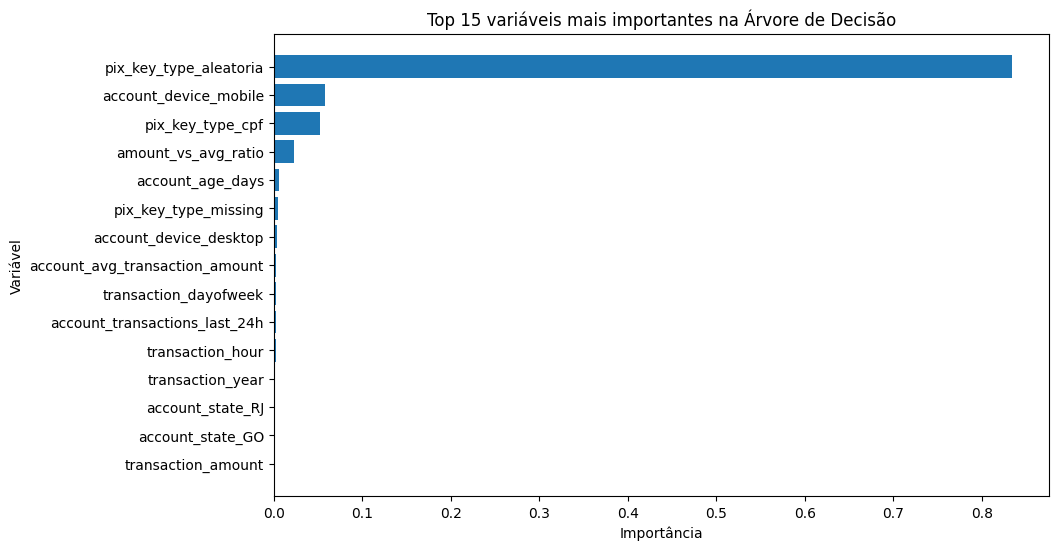

In [ ]:
import matplotlib.pyplot as plt

top_importancias = importancias_arvore.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_importancias["variavel"], top_importancias["importancia"])
plt.gca().invert_yaxis()
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Top 15 variáveis mais importantes na Árvore de Decisão")
plt.show()

### Interpretação das variáveis mais relevantes

A análise de importância da Árvore de Decisão indicou que a variável `pix_key_type_aleatoria` teve grande peso na separação entre transações fraudulentas e não fraudulentas.

Outras variáveis relevantes foram o tipo de dispositivo, o uso de chave CPF, a relação entre o valor da transação e o valor médio histórico da conta, a idade da conta, o valor médio transacionado e variáveis temporais como dia da semana e hora da transação.

Esses resultados sugerem que o modelo está capturando padrões comportamentais das transações, como tipo de chave utilizada, dispositivo, histórico da conta, valor transacionado e momento da operação.

É importante destacar que a importância das variáveis indica associação estatística dentro do dataset, mas não deve ser interpretada como causalidade.

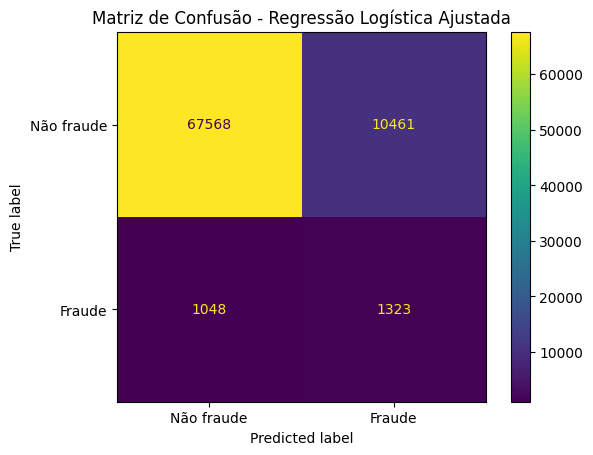

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_logistico_ajustado = confusion_matrix(y_test, y_pred_logistico_ajustado)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistico_ajustado,
    display_labels=["Não fraude", "Fraude"]
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Regressão Logística Ajustada")
plt.show()

A matriz de confusão mostra que o modelo conseguiu identificar 1.323 fraudes, mas ainda deixou passar 1.048 fraudes. Além disso, gerou 10.461 falsos positivos, ou seja, transações legítimas classificadas como suspeitas. Esse resultado evidencia o trade-off típico de modelos antifraude: aumentar a detecção pode elevar o custo operacional de revisão.

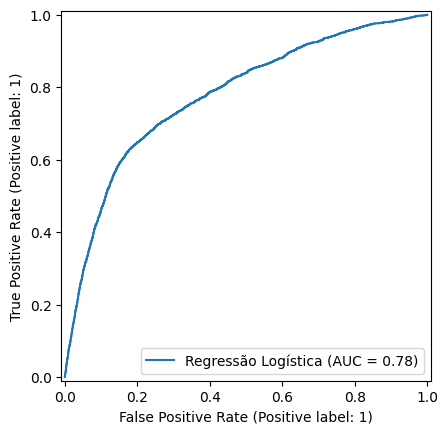

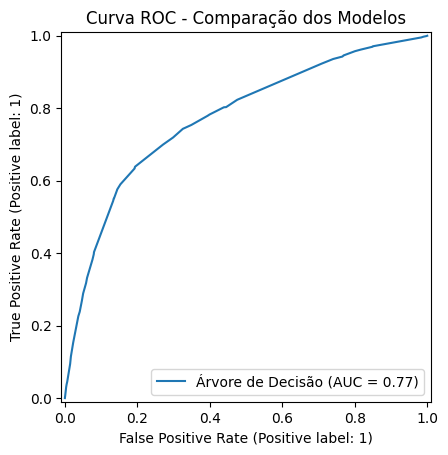

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_logistico,
    name="Regressão Logística"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_arvore,
    name="Árvore de Decisão"
)

plt.title("Curva ROC - Comparação dos Modelos")
plt.show()

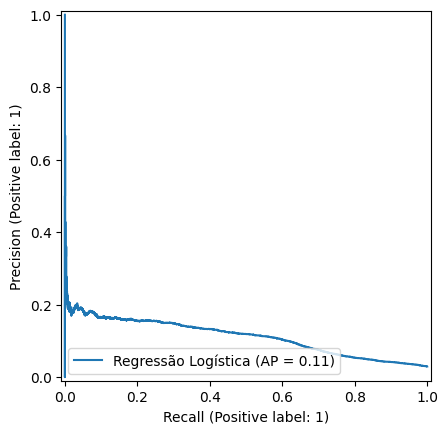

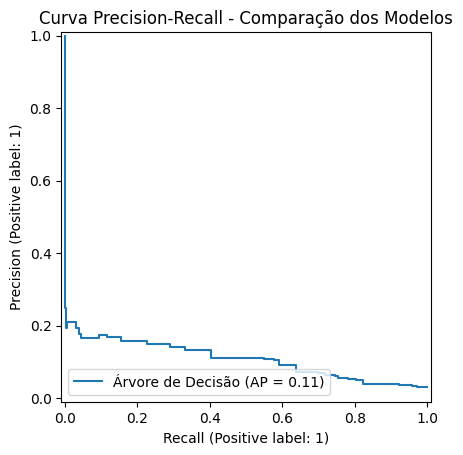

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_logistico,
    name="Regressão Logística"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_arvore,
    name="Árvore de Decisão"
)

plt.title("Curva Precision-Recall - Comparação dos Modelos")
plt.show()

Como a classe fraude representa uma pequena parcela das transações, a curva Precision-Recall é especialmente relevante. Ela mostra o trade-off entre capturar fraudes e evitar excesso de falsos alertas.

In [ ]:
coeficientes_logistico = pd.DataFrame({
    "variavel": X_train.columns,
    "coeficiente": modelo_logistico.named_steps["model"].coef_[0]
})

coeficientes_logistico["abs_coeficiente"] = coeficientes_logistico["coeficiente"].abs()

coeficientes_logistico = coeficientes_logistico.sort_values(
    by="abs_coeficiente",
    ascending=False
)

coeficientes_logistico.head(20)

,variavel,coeficiente,abs_coeficiente
24,pix_key_type_aleatoria,0.643075,0.643075
25,pix_key_type_cpf,-0.394791,0.394791
59,account_device_mobile,-0.156732,0.156732
57,account_device_desktop,0.145591,0.145591
13,amount_vs_avg_ratio,0.100640,0.100640
28,pix_key_type_telefone,-0.073690,0.073690
26,pix_key_type_email,-0.061568,0.061568
27,pix_key_type_missing,0.059198,0.059198
0,transaction_amount,0.055569,0.055569
60,account_device_tablet,0.051956,0.051956


Como usamos StandardScaler dentro do pipeline, os coeficientes estão em uma escala padronizada.

Quanto maior o valor absoluto do coeficiente, maior foi a influência daquela variável na decisão do modelo.

E o sinal indica a direção:

coeficiente positivo: aumenta a probabilidade estimada de fraude;
coeficiente negativo: reduz a probabilidade estimada de fraude.

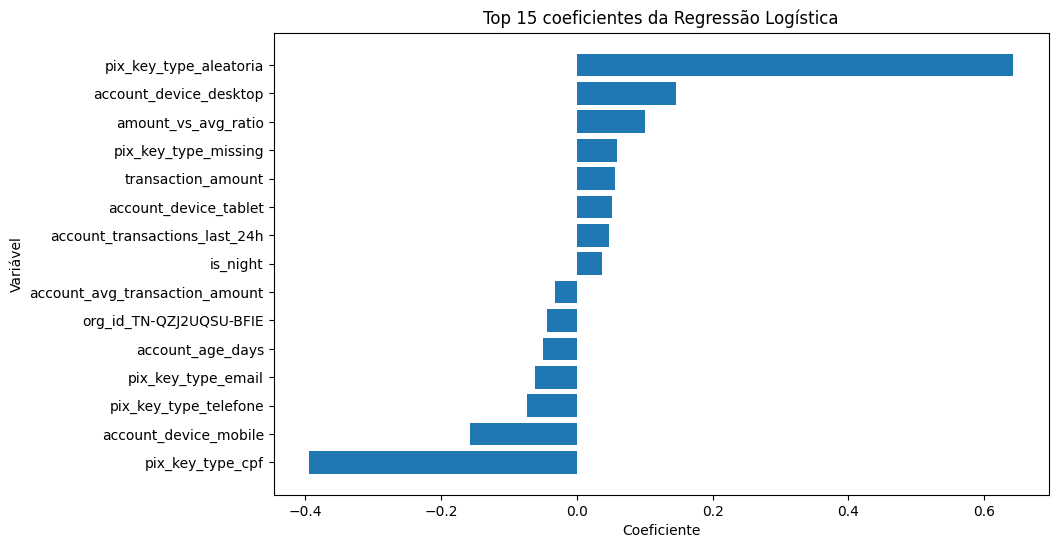

In [ ]:
top_coeficientes = coeficientes_logistico.head(15).sort_values("coeficiente")

plt.figure(figsize=(10, 6))
plt.barh(top_coeficientes["variavel"], top_coeficientes["coeficiente"])
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.title("Top 15 coeficientes da Regressão Logística")
plt.show()

### Interpretação dos coeficientes da Regressão Logística

A análise dos coeficientes da Regressão Logística ajuda a entender quais variáveis mais influenciaram a decisão do modelo final.

As variáveis com maior valor absoluto de coeficiente foram relacionadas ao tipo de chave PIX, especialmente `pix_key_type_aleatoria` e `pix_key_type_cpf`, além do dispositivo utilizado, da relação entre o valor da transação e o valor médio histórico da conta, do valor da transação, da idade da conta e de variáveis temporais.

Coeficientes positivos indicam associação com maior probabilidade estimada de fraude, enquanto coeficientes negativos indicam associação com menor probabilidade estimada de fraude.

No entanto, esses coeficientes devem ser interpretados como associações estatísticas aprendidas pelo modelo, e não como relações causais. Por exemplo, o fato de a variável `pix_key_type_aleatoria` ter coeficiente positivo não significa que esse tipo de chave cause fraude, mas sim que, dentro da base analisada, esse padrão apareceu com maior associação às transações fraudulentas.

In [ ]:
# Criando uma base de avaliação com as previsões do modelo final

resultado_teste = X_test.copy()

resultado_teste["is_fraud_real"] = y_test.values
resultado_teste["proba_fraude"] = y_proba_logistico
resultado_teste["predicao_modelo"] = y_pred_logistico_ajustado

def classificar_resultado(linha):
    if linha["is_fraud_real"] == 1 and linha["predicao_modelo"] == 1:
        return "Verdadeiro Positivo"
    elif linha["is_fraud_real"] == 0 and linha["predicao_modelo"] == 0:
        return "Verdadeiro Negativo"
    elif linha["is_fraud_real"] == 0 and linha["predicao_modelo"] == 1:
        return "Falso Positivo"
    elif linha["is_fraud_real"] == 1 and linha["predicao_modelo"] == 0:
        return "Falso Negativo"

resultado_teste["tipo_resultado"] = resultado_teste.apply(classificar_resultado, axis=1)

resultado_teste["tipo_resultado"].value_counts()

,count
tipo_resultado,
Verdadeiro Negativo,67568
Falso Positivo,10461
Verdadeiro Positivo,1323
Falso Negativo,1048


In [ ]:
variaveis_analise_erro = [
    "transaction_amount",
    "account_age_days",
    "account_transactions_last_24h",
    "account_avg_transaction_amount",
    "amount_vs_avg_ratio",
    "transaction_hour",
    "transaction_dayofweek",
    "is_night",
    "is_weekend"
]

analise_erros_numericas = resultado_teste.groupby("tipo_resultado")[variaveis_analise_erro].mean()

analise_erros_numericas

,transaction_amount,account_age_days,account_transactions_last_24h,account_avg_transaction_amount,amount_vs_avg_ratio,transaction_hour,transaction_dayofweek,is_night,is_weekend
tipo_resultado,,,,,,,,,
Falso Negativo,2961.935029,339.337786,2.057252,1504.831145,2.145437,11.895992,3.027672,0.075382,0.285305
Falso Positivo,2867.533509,335.679763,2.063569,1518.574885,2.036164,11.742854,2.975911,0.077430,0.279992
Verdadeiro Negativo,2732.080852,359.980938,1.985170,1561.890325,1.906566,11.755121,2.984534,0.070285,0.284824
Verdadeiro Positivo,2998.718330,339.046863,2.083144,1507.228549,2.164417,11.473923,2.957672,0.092971,0.284203


In [ ]:
resultado_teste.groupby("tipo_resultado")["proba_fraude"].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_resultado,,,,,,,,
Falso Negativo,1048.0,0.376231,0.129542,0.127724,0.286424,0.346944,0.456409,0.709957
Falso Positivo,10461.0,0.788203,0.051491,0.710007,0.743605,0.777060,0.834664,0.933406
Verdadeiro Negativo,67568.0,0.308769,0.111622,0.025349,0.224025,0.295781,0.370306,0.709949
Verdadeiro Positivo,1323.0,0.804817,0.053055,0.710103,0.757962,0.808950,0.850359,0.931426


### Análise de erros

Após a escolha do modelo final, foi realizada uma análise dos erros de classificação, separando os casos em verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos.

Essa análise é importante porque permite entender não apenas o desempenho agregado do modelo, mas também os tipos de transações em que ele falha. Em problemas de fraude, os falsos negativos representam fraudes que não foram detectadas, enquanto os falsos positivos representam transações legítimas que seriam sinalizadas para revisão.

A avaliação dos erros por características das transações ajuda a identificar padrões relevantes, como diferenças no valor transacionado, idade da conta, horário da operação, intensidade de transações recentes e distância entre o valor atual e o comportamento médio histórico da conta.

Essa etapa reforça que a implantação de um modelo antifraude deve considerar tanto métricas técnicas quanto impactos operacionais e de negócio.

A análise das probabilidades estimadas reforça esse diagnóstico. Os verdadeiros positivos apresentaram probabilidade média de fraude de aproximadamente 0,805, enquanto os falsos positivos apresentaram média de aproximadamente 0,788. Essa proximidade indica que parte das transações legítimas sinalizadas como fraude possuía características muito semelhantes às fraudes reais, o que explica o volume de falsos positivos.

Já os falsos negativos apresentaram probabilidade média de aproximadamente 0,376, abaixo do threshold escolhido. Isso sugere que muitas fraudes não detectadas não apresentavam, nas variáveis disponíveis, sinais suficientemente fortes para serem classificadas como suspeitas pelo modelo.

Portanto, os erros do modelo indicam duas limitações importantes: a sobreposição entre padrões de transações legítimas e fraudulentas e a possível ausência de variáveis adicionais que ajudem a distinguir melhor casos mais sutis de fraude.

## Deployment

Embora o projeto não tenha como objetivo implantar o modelo em produção, foi elaborado um plano conceitual de deployment para demonstrar como a solução poderia ser aplicada em um cenário real de prevenção a fraudes em transações PIX.

### Proposta de implantação

Em um ambiente real, o modelo poderia ser integrado ao fluxo de autorização das transações PIX. Antes da aprovação final da transação, os dados da operação seriam enviados para uma camada de decisão, responsável por calcular a probabilidade de fraude em tempo quase real.

O fluxo proposto seria:

1. O usuário inicia uma transação PIX.
2. O sistema coleta informações da transação, da conta, do dispositivo e do histórico recente.
3. As variáveis são transformadas no mesmo padrão utilizado no treinamento do modelo.
4. O modelo calcula a probabilidade de fraude.
5. A transação recebe uma decisão conforme o threshold definido:
   - baixa probabilidade: aprovar automaticamente;
   - probabilidade intermediária: enviar para autenticação adicional ou revisão;
   - alta probabilidade: bloquear preventivamente ou acionar análise antifraude.

Essa abordagem permitiria que o combate à fraude fosse preventivo, e não apenas reativo após a conclusão da transação.

### Monitoramento do modelo

Após a implantação, o modelo precisaria ser monitorado continuamente. Em problemas de fraude, os padrões mudam com frequência, pois fraudadores adaptam seu comportamento quando novas barreiras são criadas.

Os principais pontos de monitoramento seriam:

- taxa de transações classificadas como suspeitas;
- taxa de fraudes detectadas;
- volume de falsos positivos;
- volume de falsos negativos identificados posteriormente;
- distribuição das principais variáveis de entrada;
- variação da taxa de fraude ao longo do tempo;
- queda de métricas como recall, precisão e PR-AUC.

Esse acompanhamento permitiria identificar degradação do modelo, mudanças no comportamento das transações e necessidade de retreinamento.

### Retreinamento e governança

Como o comportamento das fraudes pode mudar ao longo do tempo, o modelo não deveria ser considerado uma solução estática. Seria necessário definir uma política de retreinamento periódico, por exemplo mensal ou trimestral, utilizando dados mais recentes e fraudes confirmadas após investigação.

Além disso, decisões automatizadas em um contexto financeiro exigem governança. O modelo deveria manter registro das variáveis utilizadas, da versão do algoritmo, do threshold aplicado e da justificativa da decisão tomada. Esse histórico seria importante para auditoria, explicabilidade, contestação de usuários e melhoria contínua da solução.

Também seria recomendável que decisões críticas, como bloqueio definitivo de transações, não fossem tomadas apenas pelo modelo. Em muitos casos, o score de fraude deveria funcionar como apoio à decisão, combinado com regras de negócio, autenticação adicional e análise humana.

### Riscos e limitações

A implantação de um modelo antifraude envolve riscos técnicos, operacionais e éticos. Um falso positivo pode gerar bloqueio ou atraso indevido em uma transação legítima, afetando a experiência do usuário. Por outro lado, um falso negativo permite que uma fraude seja concluída, gerando prejuízo financeiro.

Outra limitação é que o modelo foi treinado com as variáveis disponíveis no dataset. Em um ambiente real, variáveis adicionais poderiam melhorar a capacidade de detecção, como histórico de relacionamento entre pagador e recebedor, reputação da conta de destino, geolocalização aproximada, comportamento do dispositivo e tentativas recentes de autenticação.

Também é necessário considerar privacidade e proteção de dados. O uso de dados transacionais deve respeitar princípios de finalidade, necessidade, segurança e transparência, especialmente em um contexto financeiro sensível.

## Conclusão

O projeto aplicou o processo CRISP-DM a um problema de detecção de fraudes em transações PIX. A análise mostrou que a base é altamente desbalanceada, o que torna inadequado avaliar modelos apenas por acurácia.

Durante a preparação dos dados, foram tratadas inconsistências, valores nulos, variáveis temporais, identificadores e variáveis categóricas. Na modelagem, foram comparadas duas abordagens principais: Regressão Logística e Árvore de Decisão, além de um baseline.

O baseline apresentou alta acurácia, mas não identificou nenhuma fraude. Já os modelos treinados conseguiram capturar parte relevante das transações fraudulentas, com destaque para a Regressão Logística com threshold ajustado, selecionada como modelo final por apresentar melhor equilíbrio entre recall, precisão, F1-score, PR-AUC e volume de falsos positivos.

Os resultados indicam que modelos de Machine Learning podem apoiar a detecção preventiva de fraudes em PIX, mas sua implantação real exigiria monitoramento contínuo, ajuste de threshold, governança, retreinamento periódico e integração com regras de negócio e análise humana.